### Citi Bike Prediction Project — Modeling

This notebook focuses on training and evaluating machine learning models to predict whether a Citi Bike station will experience low dock availability in the near future.

The goal of this model is to predict whether a Citi Bike station will have low dock availability in the near future.

The target variable is defined as:

- **low_dock_soon = 1** if future dock availability is ≤ 10% of station capacity  
- **low_dock_soon = 0** otherwise  

This is a binary classification problem with class imbalance, as low dock availability events occur less frequently than normal conditions.

The modeling approach uses features available at the current time to predict future station state.

#### Import libraries and data
This section loads the required libraries and the processed dataset used for modeling.

All preprocessing and feature engineering steps were completed in prior notebooks to ensure a clean separation between data preparation and model development.

In [1]:
# Core analysis libraries
import pandas as pd
import numpy as np
import datetime
import time

# File path locations
from pathlib import Path

# Load data pull libraries
import requests
import json

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot styling
sns.set()

# Show all columns
pd.set_option('display.max_columns', None)

#### File directories

File paths are defined here for:
- input data
- saved models
- project structure

This ensures consistency and reproducibility across the workflow.

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
CLEAN_DATA_DIR = PROJECT_ROOT / "data/clean_data"
RAW_DATA_DIR = PROJECT_ROOT / "data/raw_data"
MODELS_DIR = PROJECT_ROOT / "models"
SRC_DIR = PROJECT_ROOT / "src"
DEPLOYMENT_DIR = PROJECT_ROOT / "deployment"

In [3]:
# Load data parquet files
X_train = pd.read_parquet(CLEAN_DATA_DIR / "03_X_train_processed.parquet")
X_test = pd.read_parquet(CLEAN_DATA_DIR / "03_X_test_processed.parquet")

y_train = pd.read_parquet(CLEAN_DATA_DIR / "03_y_train.parquet").squeeze()
y_test = pd.read_parquet(CLEAN_DATA_DIR / "03_y_test.parquet").squeeze()

#### Details of data

The dataset contains station-level observations with engineered features describing:

- Station location (latitude, longitude)
- Station capacity
- Distance to nearest MTA station
- Time-based features (hour and weekday, encoded cyclically)

The target variable is:

- **low_dock_soon = 1** if future dock availability is ≤ 10% of capacity  
- **low_dock_soon = 0** otherwise  

This is a binary classification problem with class imbalance.

In [4]:
# Number of rows and columns
print("X_train cols, rows:", X_train.shape)
print("X_test cols, rows:", X_test.shape)
print("y_train cols, rows:", y_train.shape)
print("y_test cols, rows:", y_test.shape)

X_train cols, rows: (574028, 8)
X_test cols, rows: (143508, 8)
y_train cols, rows: (574028,)
y_test cols, rows: (143508,)


#### Check for class imbalance

Low dock availability events occur less frequently than normal conditions, resulting in an imbalanced target.

Because of this:
- accuracy is not a reliable metric
- evaluation focuses on PR-AUC, recall, and F1-score
- models use class weighting where applicable

In [5]:
print("Target training class distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

Target training class distribution:
lda_30min
0    487685
1     86343
Name: count, dtype: int64
lda_30min
0    0.849584
1    0.150416
Name: proportion, dtype: float64


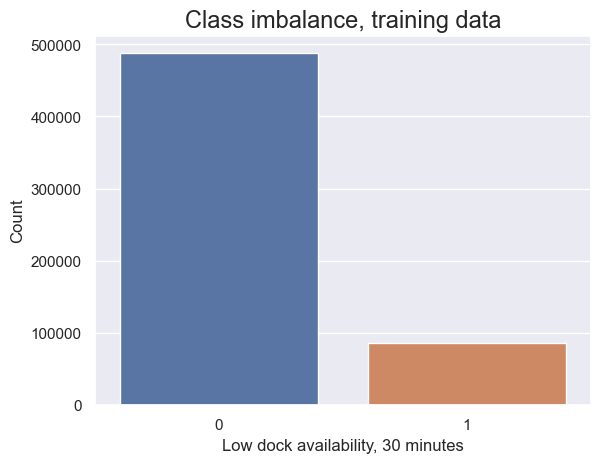

In [6]:
# Visualize training imbalance
sns.countplot(x=y_train, hue=y_train, legend=False)
plt.title("Class imbalance, training data", fontsize=17)
plt.xlabel("Low dock availability, 30 minutes")
plt.ylabel("Count")
plt.show()

In [7]:
print("Target testing class distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Target testing class distribution:
lda_30min
0    120094
1     23414
Name: count, dtype: int64
lda_30min
0    0.836845
1    0.163155
Name: proportion, dtype: float64


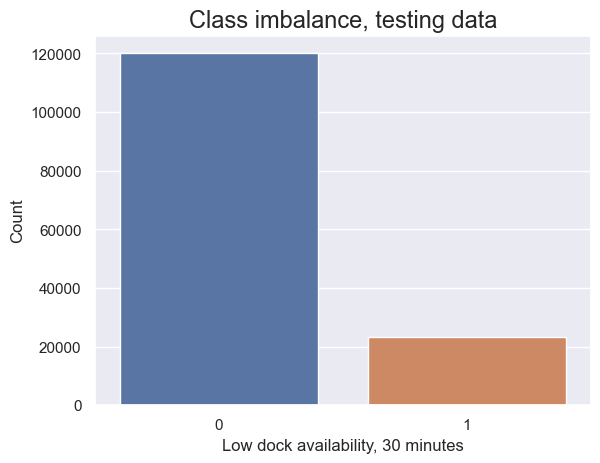

In [8]:
# Visualize testing imbalance
sns.countplot(x=y_test, hue=y_test, legend=False)
plt.title("Class imbalance, testing data", fontsize=17)
plt.xlabel("Low dock availability, 30 minutes")
plt.ylabel("Count")
plt.show()

#### Logistic Regression

Logistic Regression is used as a baseline model to establish a performance benchmark.

**Performance Summary**

- ROC-AUC: ~0.68  
- PR-AUC: ~0.30  
- Precision: Low  
- Recall: Moderate  
- F1 Score: Low  

**Interpretation**

As a linear model, Logistic Regression struggles to capture nonlinear relationships in the data, particularly interactions between time and location.

While recall is relatively moderate, the model has low precision and PR-AUC, indicating difficulty in accurately identifying low dock availability events.

This confirms that the problem requires more flexible, nonlinear modeling approaches.

In [9]:
# Import library and set config to display all model parameters
from sklearn.linear_model import LogisticRegression
from sklearn import set_config
set_config(print_changed_only=False, display="diagram")

In [10]:
# Run logistic regression
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight='balanced', dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [11]:
# Logistic regression predictions
y_pred_lr = lr.predict(X_test)

In [12]:
# Logistic regression probabilities
y_prob_lr = lr.predict_proba(X_test)[:,1]

In [13]:
# Import libabries for evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

In [14]:
# Logistic regression evaluation
lr_class_report = classification_report(y_test, y_pred_lr, output_dict=True)
pd.DataFrame(lr_class_report).round(3)

,0,1,accuracy,macro avg,weighted avg
precision,0.910,0.235,0.57,0.573,0.800
recall,0.539,0.727,0.57,0.633,0.570
f1-score,0.677,0.355,0.57,0.516,0.624
support,120094.000,23414.000,0.57,143508.000,143508.000


In [15]:
# ROC and AUC scores
roc_auc_lr = roc_auc_score(y_test, y_prob_lr).round(3)
pr_auc_lr = average_precision_score(y_test, y_prob_lr).round(3)

print("ROC-AUC:", roc_auc_lr)
print("PR-AUC:", pr_auc_lr)

ROC-AUC: 0.685
PR-AUC: 0.297


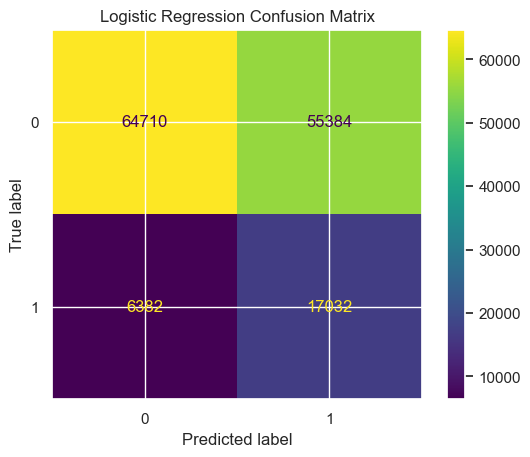

In [16]:
# Confusion matrix
lr_cf = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#### Random Forest Classifier

Random Forest is a tree-based ensemble model capable of capturing nonlinear relationships and feature interactions.

**Performance Summary**

- ROC-AUC: ~0.87  
- PR-AUC: ~0.57  
- Precision: ~0.44  
- Recall: ~0.80  
- F1 Score: ~0.57  

**Interpretation**

Random Forest significantly outperforms Logistic Regression across all metrics, particularly PR-AUC.

The model achieves strong recall, meaning it successfully identifies most low dock availability events. While precision is moderate, this is expected in an imbalanced classification setting.

Overall, Random Forest provides a strong balance between recall and precision, making it well-suited for identifying at-risk stations.

In [17]:
# Import RF Classifier
from sklearn.ensemble import RandomForestClassifier

In [18]:
# Build classifier and fit
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight='balanced',
                       criterion='gini', max_depth=10, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=10,
                       min_samples_split=20, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=200, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

In [19]:
# Predictions
y_pred_rf = rf.predict(X_test)

In [20]:
# Probabilities
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [21]:
# ROC and AUC scores
roc_auc_score_rf = roc_auc_score(y_test, y_prob_rf).round(3)
pr_auc_rf = average_precision_score(y_test, y_prob_rf).round(3)

print("ROC-AUC:", roc_auc_score_rf)
print("PR-AUC:", pr_auc_rf)

ROC-AUC: 0.871
PR-AUC: 0.575


In [22]:
# RF Classifier class report
rf_class_report = classification_report(y_test, y_pred_rf, output_dict=True)
pd.DataFrame(rf_class_report).round(3)

,0,1,accuracy,macro avg,weighted avg
precision,0.954,0.433,0.796,0.693,0.869
recall,0.794,0.805,0.796,0.800,0.796
f1-score,0.867,0.563,0.796,0.715,0.817
support,120094.000,23414.000,0.796,143508.000,143508.000


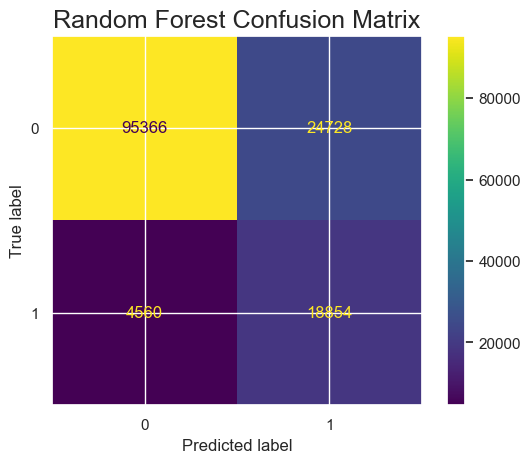

In [23]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix", fontsize=18)
plt.show()

#### XGBoost Classifier
XGBoost is a gradient boosting model designed for high performance on structured/tabular data.

**Performance Summary**
- ROC-AUC: ~0.88  
- PR-AUC: ~0.57  
- Precision: ~0.44  
- Recall: ~0.83  
- F1 Score: ~0.58  

**Interpretation**

XGBoost performs similarly to Random Forest, with slightly higher ROC-AUC, recall, and F1 score.

The higher recall indicates that XGBoost captures slightly more of the minority class, though PR-AUC remains very close to Random Forest.

Given the minimal performance difference, the added complexity of XGBoost may not justify its use over Random Forest in this case.

In [24]:
# Import library
from xgboost import XGBClassifier

In [25]:
# Build XGBClassifier and fit
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [26]:
# Predictions
y_pred_xgb = xgb.predict(X_test)

In [27]:
# Probabilities
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [28]:
# ROC and AUC scores
roc_auc_score_xgb = roc_auc_score(y_test, y_prob_xgb).round(3)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb).round(3)

print("ROC-AUC:", roc_auc_score_xgb)
print("PR-AUC:", pr_auc_xgb)

ROC-AUC: 0.879
PR-AUC: 0.567


In [29]:
# XGB Classifier class report
xgb_class_report = classification_report(y_test, y_pred_xgb, output_dict=True)
pd.DataFrame(xgb_class_report).round(3)

,0,1,accuracy,macro avg,weighted avg
precision,0.961,0.443,0.802,0.702,0.877
recall,0.796,0.834,0.802,0.815,0.802
f1-score,0.871,0.579,0.802,0.725,0.823
support,120094.000,23414.000,0.802,143508.000,143508.000


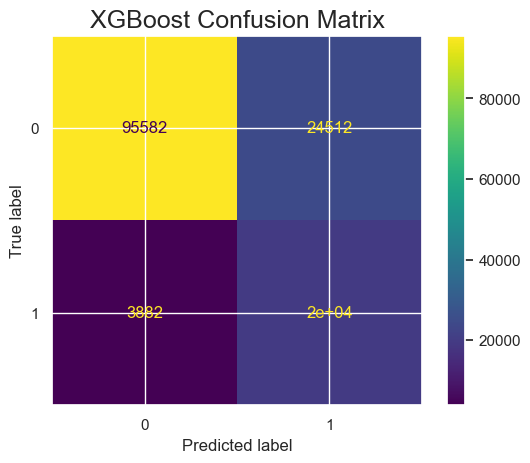

In [30]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("XGBoost Confusion Matrix", fontsize=18)
plt.show()

#### TensorFlow

A feedforward neural network is implemented to benchmark deep learning performance on this dataset.

**Performance Summary**

- ROC-AUC: 0.815
- PR-AUC: 0.462
- Precision: 0.528
- Recall: 0.312
- F1 Score: 0.393

**Interpretation**

The neural network does not outperform tree-based models on this tabular dataset.

While it is capable of learning nonlinear patterns, tree-based models like Random Forest and XGBoost are generally better suited for structured data with relatively small feature sets.

This result aligns with common observations that deep learning does not consistently outperform traditional methods on tabular problems.

In [31]:
# Import TensorFlow and set random seed
import tensorflow as tf
tf.random.set_seed(42)

In [32]:
# Convert to tensors
X_train_tensor = tf.convert_to_tensor(X_train, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_train_tensor = tf.convert_to_tensor(y_train, dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test, dtype=tf.float32)

In [33]:
# Build model
tf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_tensor.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [34]:
# Compile and summarize
tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

tf_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Early stopping if convergence is reached
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [36]:
# Train model
history = tf_model.fit(
    X_train_tensor,
    y_train_tensor,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/10
3588/3588 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8503 - loss: 0.3883 - precision: 0.3593 - recall: 0.0124 - val_accuracy: 0.8373 - val_loss: 0.3961 - val_precision: 0.5910 - val_recall: 0.0822
Epoch 2/10
3588/3588 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8583 - loss: 0.3531 - precision: 0.6908 - recall: 0.0589 - val_accuracy: 0.8398 - val_loss: 0.3864 - val_precision: 0.6425 - val_recall: 0.0907
Epoch 3/10
3588/3588 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.8622 - loss: 0.3396 - precision: 0.6914 - recall: 0.1079 - val_accuracy: 0.8411 - val_loss: 0.3804 - val_precision: 0.6425 - val_recall: 0.1080
Epoch 4/10
3588/3588 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.8635 - loss: 0.3309 - precision: 0.6701 - recall: 0.1347 - val_accuracy: 0.8415 - val_loss: 0.3734 - val_precision: 0.6085 - val_recall: 0.1411
Epoch 5/10
3588/3588 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.8648 - loss: 0.3246 - precision: 0.6606 - recall: 0.1583 - val_accuracy: 0.8414

In [37]:
# Model evaluaton
y_prob_tf = tf_model.predict(X_test_tensor, verbose=0).ravel()
y_pred_tf = (y_prob_tf >= 0.5).astype(int)

roc_auc_tf = roc_auc_score(y_test, y_prob_tf).round(3)
pr_auc_tf = average_precision_score(y_test, y_prob_tf).round(3)

print("ROC-AUC:", roc_auc_tf)
print("PR-AUC:", pr_auc_tf)

ROC-AUC: 0.815
PR-AUC: 0.462


In [38]:
# Evaluate model
tf_results = tf_model.evaluate(X_test_tensor, y_test_tensor, batch_size=128, verbose=0)

print(f"Test loss: {tf_results[0]:.3f}")
print(f"Test accuracy: {tf_results[1]:.3f}")
print(f"Test precision: {tf_results[2]:.3f}")
print(f"Test recall: {tf_results[3]:.3f}")

Test loss: 0.360
Test accuracy: 0.842
Test precision: 0.528
Test recall: 0.312


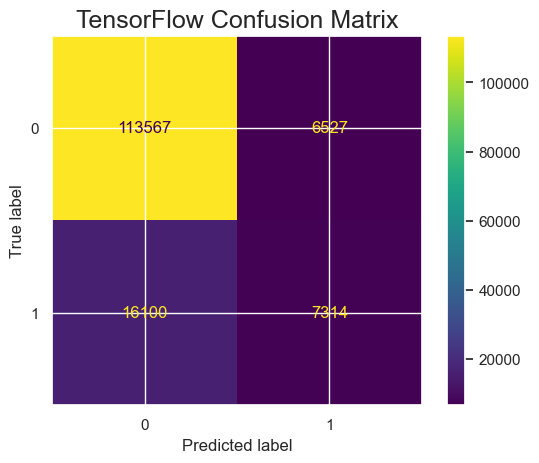

In [39]:
# TensorFlow confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tf)
plt.title("TensorFlow Confusion Matrix", fontsize=18)
plt.show()

In [40]:
# Classification report for metrics compilation
tf_class_report = classification_report(y_test, y_pred_tf, output_dict=True)

#### Plot ROC and PR-Curves

ROC and Precision-Recall curves are used to evaluate model performance across different classification thresholds.

**Key Observations**

- All models show strong ROC-AUC performance, with tree-based models (Random Forest and XGBoost) achieving values around **0.87–0.88**, indicating strong overall separability between classes.

- However, due to class imbalance, the **Precision-Recall curve provides a more meaningful evaluation**.

- Random Forest and XGBoost achieve **PR-AUC values around 0.57**, significantly outperforming Logistic Regression (~0.30), which struggles to capture the minority class.

- The gap between ROC-AUC and PR-AUC highlights the impact of class imbalance and reinforces the importance of focusing on PR-AUC for model selection.

**Takeaway**

While ROC curves suggest all models perform well, the PR curves reveal that **tree-based models are substantially better at identifying low dock availability events**, making them more suitable for this problem.

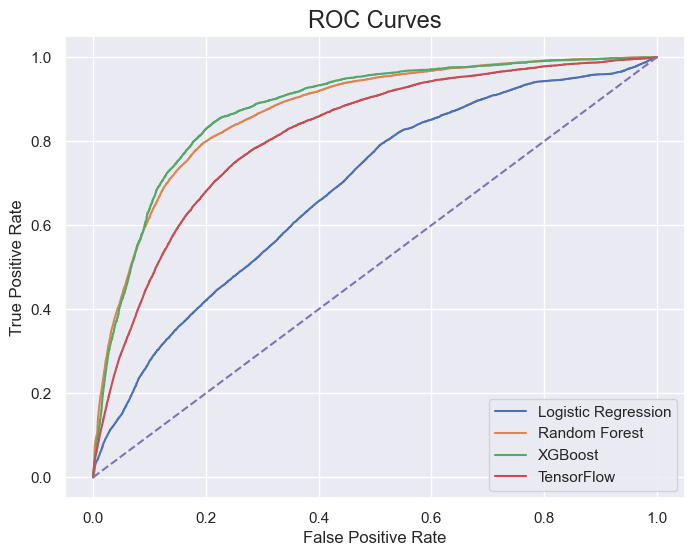

In [41]:
# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_tf, tpr_tf, _ = roc_curve(y_test, y_prob_tf)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot(fpr_tf, tpr_tf, label="TensorFlow")

plt.plot([0,1], [0,1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves", fontsize=17)

plt.legend()

plt.show()

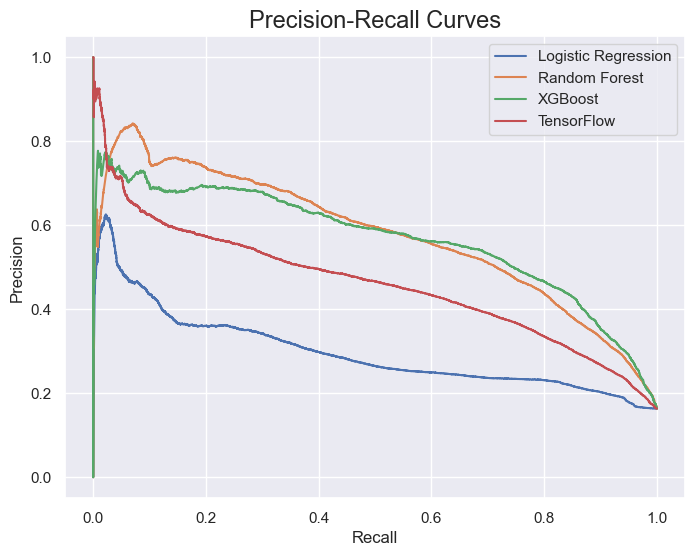

In [42]:
#P-R curves
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
prec_tf, rec_tf, _ = precision_recall_curve(y_test, y_prob_tf)

plt.figure(figsize=(8,6))

plt.plot(rec_lr, prec_lr, label="Logistic Regression")
plt.plot(rec_rf, prec_rf, label="Random Forest")
plt.plot(rec_xgb, prec_xgb, label="XGBoost")
plt.plot(rec_tf, prec_tf, label="TensorFlow")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves", fontsize=17)

plt.legend()

plt.show()

#### Compile metrics

Because the target variable is imbalanced, PR-AUC provides a more informative measure of how well the model identifies the minority class compared to ROC-AUC or accuracy.

**Performance Summary**

- Logistic Regression underperforms with a PR-AUC of ~0.30, indicating limited ability to detect low dock availability events.

- Random Forest and XGBoost significantly improve performance, both achieving PR-AUC values around **0.57**, more than doubling the baseline.

- Tree-based models also show strong recall (~0.80+), meaning they successfully identify most at-risk stations.

**Tradeoffs**

- Precision remains moderate (~0.44), which is expected in an imbalanced classification setting.
- Higher recall comes at the cost of more false positives, but this is acceptable for a risk-detection use case.

**Takeaway**

The compiled metrics confirm that **tree-based models are significantly more effective than linear models**, with Random Forest and XGBoost providing strong and consistent performance.

In [43]:
# Logistic Regression metrics
lr_metrics = [
    "Logistic Regression",
    roc_auc_lr, 
    pr_auc_lr,
    round(lr_class_report["1"]["precision"], 3),
    round(lr_class_report["1"]["recall"], 3),
    round(lr_class_report["1"]["f1-score"], 3)
]

In [44]:
# Random Forest Metrics
rf_metrics = [
    "Random Forest Classifier",
    roc_auc_score_rf, 
    pr_auc_rf, 
    round(rf_class_report["1"]["precision"], 3),
    round(rf_class_report["1"]["recall"], 3),
    round(rf_class_report["1"]["f1-score"], 3)
]

In [45]:
# XGBoost Metrics
xgb_metrics = [
    "XGB Classifier",
    roc_auc_score_xgb, 
    pr_auc_xgb, 
    round(xgb_class_report["1"]["precision"], 3),
    round(xgb_class_report["1"]["recall"], 3),
    round(xgb_class_report["1"]["f1-score"], 3)
]

In [46]:
# TensorFlow Metrics
tf_metrics = [
    "TensorFlow",
    roc_auc_tf, 
    pr_auc_tf, 
    round(tf_class_report["1"]["precision"], 3),
    round(tf_class_report["1"]["recall"], 3),
    round(tf_class_report["1"]["f1-score"], 3)
]

#### Model comparison table

The table below summarizes model performance across all evaluation metrics.

**Interpretation**

- **Logistic Regression** performs significantly worse across all metrics, confirming that linear models are insufficient for this problem.

- **Random Forest and XGBoost** perform similarly, both achieving strong ROC-AUC and PR-AUC scores.

- **XGBoost** shows slightly higher recall and F1 score, indicating better detection of the minority class.

- **Random Forest** achieves the highest PR-AUC, making it the strongest model based on the primary evaluation metric.

**Model Selection Decision**

Given the minimal performance difference between Random Forest and XGBoost:

- Random Forest was selected as the final model due to:
  - Slightly higher PR-AUC
  - Simpler implementation and tuning
  - Easier interpretability

**Takeaway**

Tree-based ensemble models provide a substantial improvement over linear models, with Random Forest offering the best balance of performance and simplicity for this use case.

In [47]:
# Make model comparison table
model_comparison = pd.DataFrame(columns=[
    "Model Name", 
    "ROC-AUC", 
    "PR-AUC",
    "Precision", 
    "Recall",
    "F1-Score"
])

model_comparison.loc[len(model_comparison)] = lr_metrics
model_comparison.loc[len(model_comparison)] = rf_metrics
model_comparison.loc[len(model_comparison)] = xgb_metrics
model_comparison.loc[len(model_comparison)] = tf_metrics

model_comparison.sort_values(by="PR-AUC", ascending=False)

,Model Name,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
1,Random Forest Classifier,0.871,0.575,0.433,0.805,0.563
2,XGB Classifier,0.879,0.567,0.443,0.834,0.579
3,TensorFlow,0.815,0.462,0.528,0.312,0.393
0,Logistic Regression,0.685,0.297,0.235,0.727,0.355


#### Export model
After selecting Random Forest as the final model, the model is saved as a serialized `.joblib` file. This exported model will be used in the next stage of the project for inference and AWS deployment.

In [48]:
# Save model
import joblib

joblib.dump(rf, MODELS_DIR / "citi_bike_random_forest_model.joblib")

['C:\\Users\\jac67\\Documents\\Data and Analytics\\Python\\citi-bike-prediction\\models\\citi_bike_random_forest_model.joblib']